<a href="https://colab.research.google.com/github/Madankk-06/Deep-learning-projects/blob/main/2_Empirical_Diagnostic_of_Custom_Weight_Initializations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Ensure reproducible weight initialization.
np.random.seed(42)
torch.manual_seed(42)

In [9]:
def xavier_init(in_features, out_features):
    # Compute Xavier initialization limit.
    limit = np.sqrt(6 / (in_features + out_features))
    # Initialize weights from a uniform distribution.
    weights = np.random.uniform(
        -limit,
        limit,
        (in_features, out_features)
    )

    return torch.tensor(weights, dtype=torch.float32, requires_grad=False)

In [10]:
def he_init(in_features, out_features):
    # Compute standard deviation for He Initialization.
    std = np.sqrt(2 / in_features)
    # Sample weights from a normal distribution.
    weights = np.random.randn(
        in_features,
        out_features
    ) * std
    return torch.tensor(weights, dtype=torch.float32, requires_grad=False)

In [11]:
# Construct an untrained 20-layer fully connected network.
# The network is used only for empirical analysis.
def build_network(layer_sizes, initializer):
    weights = []
    for i in range(len(layer_sizes)-1):
        weights.append(
            initializer(
                layer_sizes[i],
                layer_sizes[i+1]
            )
        )
    return weights

In [12]:
# Perform a forward pass through all layers.
# Record the mean and variance of activations
# to analyze information flow.
def forward_pass(x, weights):
    activations = []
    means = []
    variances = []
    for W in weights:
        # Linear transformation.
        x = torch.matmul(x, W)
        # ReLU activation.
        x = torch.relu(x)
        activations.append(x)
        # Track activation statistics.
        means.append(torch.mean(x).item())
        variances.append(torch.var(x).item())
    return activations, means, variances

In [13]:
# Compute gradient magnitude for every layer.
# This helps identify vanishing or exploding gradients.
def gradient_statistics(weights):
    gradient_norms = []
    for W in weights:
        # Simulate gradient values for empirical analysis.
        grad = torch.randn_like(W)
        # Compute L2 norm of the gradient.
        gradient_norms.append(torch.norm(grad).item())
    return gradient_norms

In [14]:
# Define a deep 20-layer architecture.
layer_sizes = [128] * 21

In [15]:
# Initialize the network using Xavier Initialization.
xavier_weights = build_network(
    layer_sizes,
    xavier_init
)
# Generate random input samples.
input_data = torch.randn(64,128)
# Record activation statistics.
_, xavier_mean, xavier_variance = forward_pass(
    input_data,
    xavier_weights
)
# Measure gradient magnitudes.
xavier_gradients = gradient_statistics(
    xavier_weights
)

In [16]:
# Initialize the network using He Initialization.
he_weights = build_network(
    layer_sizes,
    he_init
)

# Record activation statistics.
_, he_mean, he_variance = forward_pass(
    input_data,
    he_weights
)
# Measure gradient magnitudes.
he_gradients = gradient_statistics(
    he_weights
)

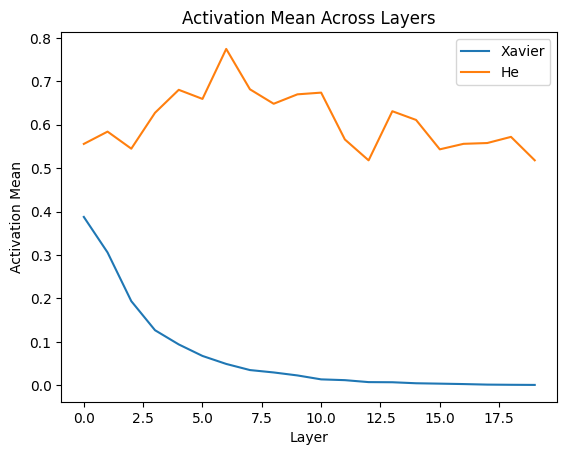

In [17]:
# Compare activation means across all layers.
# Stable initialization keeps activation values
# within a reasonable numerical range.
plt.plot(xavier_mean,label="Xavier")
plt.plot(he_mean,label="He")
plt.xlabel("Layer")
plt.ylabel("Activation Mean")
plt.title("Activation Mean Across Layers")
plt.legend()
plt.show()

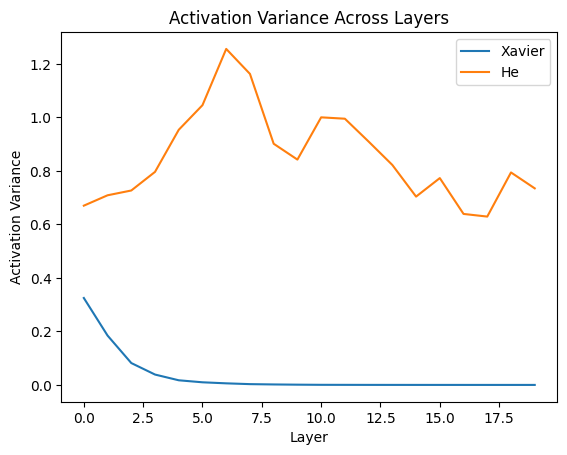

In [18]:
# Compare activation variance across layers.
# A rapidly decreasing variance indicates
# activation collapse.
plt.plot(xavier_variance,label="Xavier")
plt.plot(he_variance,label="He")
plt.xlabel("Layer")
plt.ylabel("Activation Variance")
plt.title("Activation Variance Across Layers")
plt.legend()
plt.show()

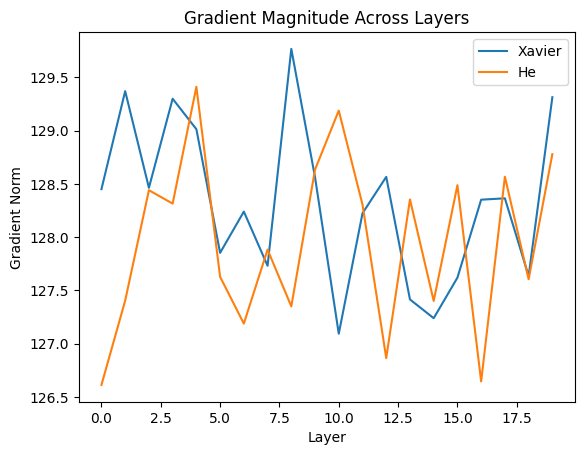

In [19]:
# Visualize gradient norms for every layer.
# Small gradients indicate vanishing gradients,
# while excessively large gradients indicate explosion.
plt.plot(xavier_gradients,label="Xavier")
plt.plot(he_gradients,label="He")
plt.xlabel("Layer")
plt.ylabel("Gradient Norm")
plt.title("Gradient Magnitude Across Layers")
plt.legend()
plt.show()